# Peakflo — Expense Account Classification
## Leakage-Safe, Group-Aware ML Pipeline

### ML Engineer Intern Take-Home Assignment

**Target:** `accountName`

This notebook is a fresh implementation focused on both **performance and evaluation integrity**.

It is designed to:

- perform broader exploratory data analysis;
- prevent target leakage;
- keep related `_id` groups together;
- freeze the final test set before model selection;
- compare a strong sparse-text model with an optional CatBoost model;
- use leakage-safe vendor/text lookup rules;
- diagnose overfitting;
- provide category-level and error analysis;
- produce a submission-ready Results section.

The goal is to obtain the strongest result that is defensible under a leakage-safe protocol. A score above 90% is treated as a stretch goal, not something that should be manufactured by contaminating the test set.

# 1. Executive Summary

The supplied dataset contains 4,894 expense transactions and 103 `accountName` classes. The previous notebook achieved **86.88% group-aware CV accuracy and 85.96% final test accuracy**, but its training accuracy was **99.41%**, producing a 13.44 percentage-point train/test gap. That is a meaningful overfitting signal.

The revised approach broadens the EDA and adds several sources of legitimate predictive signal: normalized transaction text, word and character TF-IDF, vendor identity, amount transformations, text-length statistics, and carefully controlled repetition rules. It also evaluates CatBoost when available because this problem contains both categorical and text information and may benefit from nonlinear vendor/amount interactions.

The most important leakage controls are that `accountId` is never a predictive feature, `_id` is used only as a grouping key, and every target-derived vendor/text mapping is fitted only on training data. Hyperparameters and rule thresholds are selected without using the final test labels.

# 2. Data Analysis

## 2.1 Feature roles

| Field | Role | Reason |
|---|---|---|
| `itemName` | Feature | Expense semantics |
| `itemDescription` | Feature | Transaction context |
| `vendorId` | Feature | Vendor-specific accounting patterns |
| `itemTotalAmount` | Feature | Numerical accounting signal |
| `_id` | Grouping only | Prevents related rows crossing evaluation boundaries |
| `accountId` | Excluded | Direct target-identifying information |
| `accountName` | Target | Account to predict |

A field can be used for **validation grouping** without being supplied to the classifier.

## 2.2 Imports and reproducibility

The loader explicitly handles MongoDB Extended JSON. This avoids the `TypeError: unhashable type: 'dict'` problem that can occur when Pandas receives `_id` as a nested `{"$oid": ...}` dictionary.

The notebook does not generate synthetic data if the supplied file is missing.

In [31]:
import json
import re
import warnings
from pathlib import Path

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from IPython.display import display

from sklearn.base import clone
from sklearn.compose import ColumnTransformer
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    balanced_accuracy_score,
    classification_report,
    confusion_matrix,
)
from sklearn.model_selection import StratifiedGroupKFold, GroupShuffleSplit
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import OneHotEncoder, StandardScaler
from sklearn.svm import LinearSVC

warnings.filterwarnings("ignore")

RANDOM_STATE = 42
np.random.seed(RANDOM_STATE)

sns.set_theme(style="whitegrid")
pd.set_option("display.max_columns", 100)
pd.set_option("display.max_colwidth", 120)

DATA_PATH = Path("accounts-bills.json")

if not DATA_PATH.exists():
    raise FileNotFoundError(
        "accounts-bills.json was not found. Put it in the same folder as this notebook."
    )

print("Dataset path:", DATA_PATH.resolve())

Dataset path: C:\Users\Shubham\Peakflo\accounts-bills.json


## 2.3 Robust JSON loading

MongoDB Extended JSON may represent `_id` as:

```text
{"$oid": "..."}
```

`json_normalize` can turn this into `_id.$oid`. We explicitly convert it back into a stable string `_id`, which is then used only for grouping.

In [32]:
with open(DATA_PATH, "r", encoding="utf-8") as f:
    records = json.load(f)

if not isinstance(records, list):
    raise ValueError(
        f"Expected a list of transaction records, got {type(records).__name__}"
    )

df_raw = pd.json_normalize(records)

# Handle MongoDB Extended JSON ObjectId.
if "_id.$oid" in df_raw.columns:
    df_raw = df_raw.rename(columns={"_id.$oid": "_id"})
elif "_id" in df_raw.columns:
    def normalize_id(value):
        if isinstance(value, dict):
            if "$oid" in value:
                return str(value["$oid"])
            return json.dumps(value, sort_keys=True)
        return str(value)
    df_raw["_id"] = df_raw["_id"].apply(normalize_id)
else:
    raise ValueError(
        "Could not find _id. Available columns: "
        + str(df_raw.columns.tolist())
    )

df_raw["_id"] = df_raw["_id"].astype(str).str.strip()

# Convert any unexpected nested dictionaries into strings.
# This prevents Pandas hashing/factorization errors.
for col in df_raw.columns:
    if col == "_id":
        continue
    if df_raw[col].apply(lambda x: isinstance(x, dict)).any():
        df_raw[col] = df_raw[col].apply(
            lambda x: json.dumps(x, sort_keys=True)
            if isinstance(x, dict)
            else x
        )

print("=" * 70)
print("DATASET LOADED")
print("=" * 70)
print("Rows:", len(df_raw))
print("Columns:", len(df_raw.columns))
print("Unique _id:", df_raw["_id"].nunique())
print("Columns:", df_raw.columns.tolist())

display(df_raw.head())

DATASET LOADED
Rows: 4894
Columns: 7
Unique _id: 3181
Columns: ['vendorId', 'itemName', 'itemDescription', 'accountId', 'accountName', 'itemTotalAmount', '_id']


,vendorId,itemName,itemDescription,accountId,accountName,itemTotalAmount,_id
0,6m656Er7lbi8RYz2ny1J,1225 Business 2Gbps - monthly subscription fee,1225 Business 2Gbps - monthly subscription fee,88AW5nmkLvMe1GthZ6FL,619206 Telephone & Internet,888.00,69606546de1e297ec29890f2
1,VtxikZ7HI6Jwqueemjch,1225-0227 media monitoring,1225-0227 media monitoring,sWG9pai5DiLXaKs6s86G,134004 Prepaid Subscription,17765.00,695b5304d09b4ceb96e5288e
2,jdmr9pJ0WHqso4Wh3hCa,0226 Branch,0226 Branch,C0SB5vR0gCikdKjmT8Ep,611202 Online Subscription/Tool,7083.34,69800f97e85d532c0db71c7e
3,A17M26ij1P8uGEnRFtP0,0126 GAM (SG),0126 GAM (SG),IbDOq9NsCcO8rSg7Uk1y,511301 Display COGS,2609.11,6981a56e83888e7f4589cf09
4,A17M26ij1P8uGEnRFtP0,0126 GAM (Chotot & Mudah),0126 GAM (Chotot & Mudah),w5hjK0IooxdDp9Feeeuy,132098 IC Clearing account - Paid on Behalf,1243.22,6981a56e83888e7f4589cf09


## 2.4 Schema, missingness, duplicates and group structure

The dataset is audited before modeling.

Exact duplicates are reported rather than automatically removed. The `_id` audit checks whether transactions are grouped and whether groups contain multiple account labels.

In [34]:
TARGET = "accountName"
AMOUNT = "itemTotalAmount"

required = [
    "_id",
    "vendorId",
    "itemName",
    "itemDescription",
    "accountId",
    "accountName",
    "itemTotalAmount",
]

missing_required = [c for c in required if c not in df_raw.columns]
if missing_required:
    raise ValueError(f"Missing required columns: {missing_required}")

print("===== DATA QUALITY =====")

quality = pd.DataFrame({
    "dtype": df_raw.dtypes.astype(str),
    "missing": df_raw.isna().sum(),
    "missing_pct": 100 * df_raw.isna().mean(),
    "unique": df_raw.nunique(dropna=False),
})

display(quality)

print("Exact duplicate rows:", int(df_raw.duplicated().sum()))
print("Rows in duplicate groups:", int(df_raw.duplicated(keep=False).sum()))

group_sizes = df_raw.groupby("_id").size()
group_label_counts = df_raw.groupby("_id")[TARGET].nunique()
conflicting_groups = group_label_counts[group_label_counts > 1]

print("Unique _id groups:", group_sizes.size)
print("Multi-row _id groups:", int((group_sizes > 1).sum()))
print("Groups with multiple accountName labels:", len(conflicting_groups))

display(group_sizes.describe().to_frame("rows_per_group"))

if len(conflicting_groups):
    display(
        conflicting_groups
        .sort_values(ascending=False)
        .head(10)
        .to_frame("unique_account_labels")
    )

===== DATA QUALITY =====


,dtype,missing,missing_pct,unique
vendorId,object,0,0.000000,337
itemName,object,0,0.000000,4060
itemDescription,object,11,0.224765,4059
accountId,object,0,0.000000,97
accountName,object,0,0.000000,103
itemTotalAmount,float64,0,0.000000,2878
_id,object,0,0.000000,3181


Exact duplicate rows: 10
Rows in duplicate groups: 18
Unique _id groups: 3181
Multi-row _id groups: 801
Groups with multiple accountName labels: 388


,rows_per_group
count,3181.000000
mean,1.538510
std,1.698735
min,1.000000
25%,1.000000
50%,1.000000
75%,2.000000
max,28.000000


,unique_account_labels
_id,
66cffbae9b7ffc422df4af10,8
66a36d52c9903293bfd02e1c,8
6747d9f30fff305633bba1e0,7
667a5f41062a7c61a168188f,7
6628bc80f1886cc8aac9a9a8,7
66f3979b8c8c6576458389c3,7
66a35f4cc9903293bfcfb93b,5
6655e3c51d0fc61e9d4fc86c,5
664f29642d6099875a9945c9,5


## 2.5 Target distribution and class imbalance

The assignment has 103 account categories. Because many classes are rare, overall accuracy alone is insufficient.

We retain all classes and later report macro F1, balanced accuracy, and category-level performance.

Rows: 4894
Unique accountName classes: 103
Largest class: 611202 Online Subscription/Tool
Largest class count: 1179
Smallest class count: 1
Classes with <2 observations: 16
Classes with <5 observations: 34
Classes with <10 observations: 43
Classes with <20 observations: 59


,count
accountName,
611202 Online Subscription/Tool,1179
132098 IC Clearing account,706
619203 Supplies/Expenses,225
134001 Prepaid Operating Expense,193
614123 Employee On Record,175
132098 IC Clearing account - Paid on Behalf,131
617103 Subcontractors/Outsource,126
617205 Consultancy Expense,121
619201 Equipment Expense,114


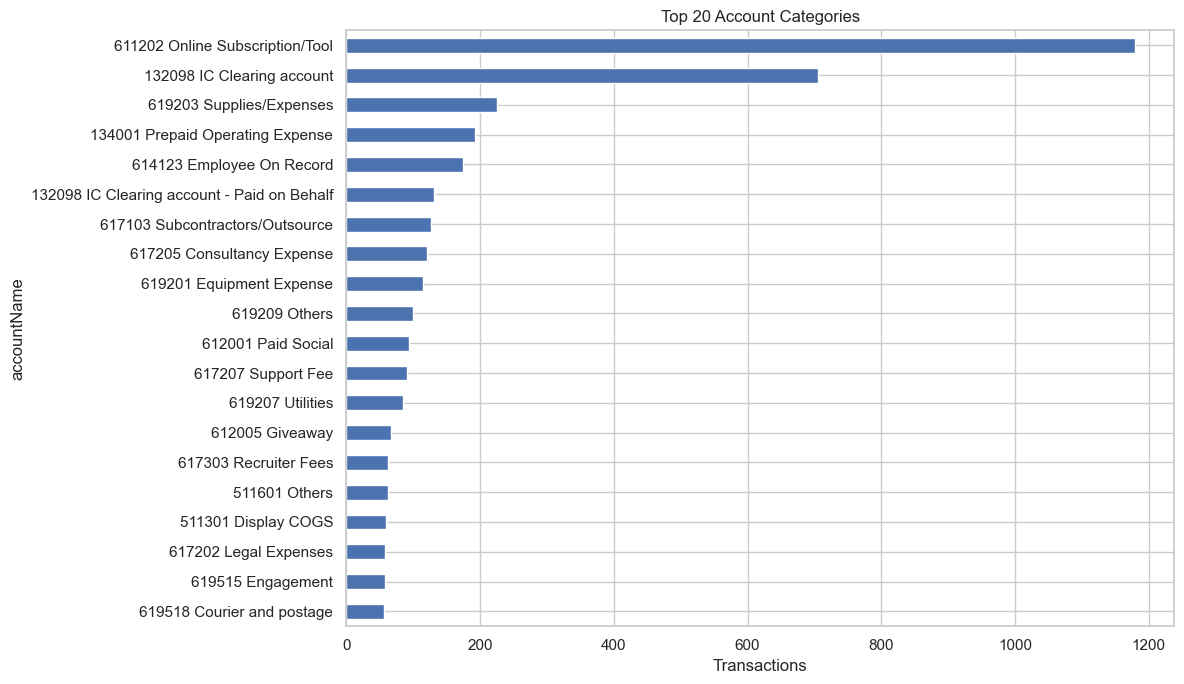

In [36]:
target_counts = df_raw[TARGET].value_counts()

print("Rows:", len(df_raw))
print("Unique accountName classes:", target_counts.size)
print("Largest class:", target_counts.index[0])
print("Largest class count:", int(target_counts.iloc[0]))
print("Smallest class count:", int(target_counts.iloc[-1]))

for threshold in [2, 5, 10, 20]:
    print(
        f"Classes with <{threshold} observations:",
        int((target_counts < threshold).sum())
    )

display(target_counts.head(20).to_frame("count"))

fig, ax = plt.subplots(figsize=(12, 7))
target_counts.head(20).sort_values().plot(kind="barh", ax=ax)
ax.set_title("Top 20 Account Categories")
ax.set_xlabel("Transactions")
ax.set_ylabel("accountName")
plt.tight_layout()
plt.show()

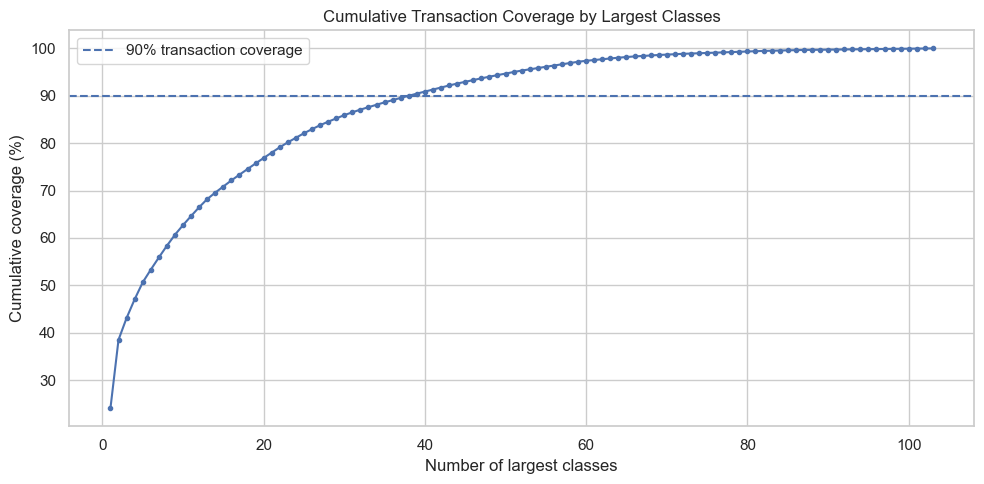

Class imbalance ratio: 1179.0x


In [38]:
coverage = (
    target_counts.cumsum()
    / target_counts.sum()
    * 100
)

fig, ax = plt.subplots(figsize=(10, 5))
ax.plot(
    np.arange(1, len(coverage) + 1),
    coverage.values,
    marker="o",
    markersize=3,
)
ax.axhline(90, linestyle="--", label="90% transaction coverage")
ax.set_title("Cumulative Transaction Coverage by Largest Classes")
ax.set_xlabel("Number of largest classes")
ax.set_ylabel("Cumulative coverage (%)")
ax.legend()
plt.tight_layout()
plt.show()

print(
    "Class imbalance ratio:",
    f"{target_counts.max() / target_counts.min():.1f}x"
)

## 2.6 Vendor concentration and vendor/account purity

Vendor identity is often a major signal in expense classification.

For each vendor we calculate:

- transaction support
- number of account categories used
- majority-account support
- purity

This analysis motivates the later vendor prior, but the prior will be fitted only on training data.

Unique vendors: 337


,vendor_transactions,vendor_accounts,majority_count,purity
vendorId,,,,
lL1pcuEf3q6ufBVg2R75,380,19,260,0.684211
A17M26ij1P8uGEnRFtP0,250,9,99,0.396000
fkPInOrYT7R0kyIdio61,216,5,103,0.476852
mPL2AaRMpMwx0DildEHU,186,6,175,0.940860
PUFLGwAsGqXRsERkjGXm,136,3,64,0.470588
xqp1L1yWtYW4mdFSx359,128,3,70,0.546875
hN0x4DfKdzf4DOrM5ec5,96,3,93,0.968750
9uttFKe5Q4InVwOHZoV7,78,4,34,0.435897
bfN8jYCNYKQFk7yN2vvN,77,7,37,0.480519


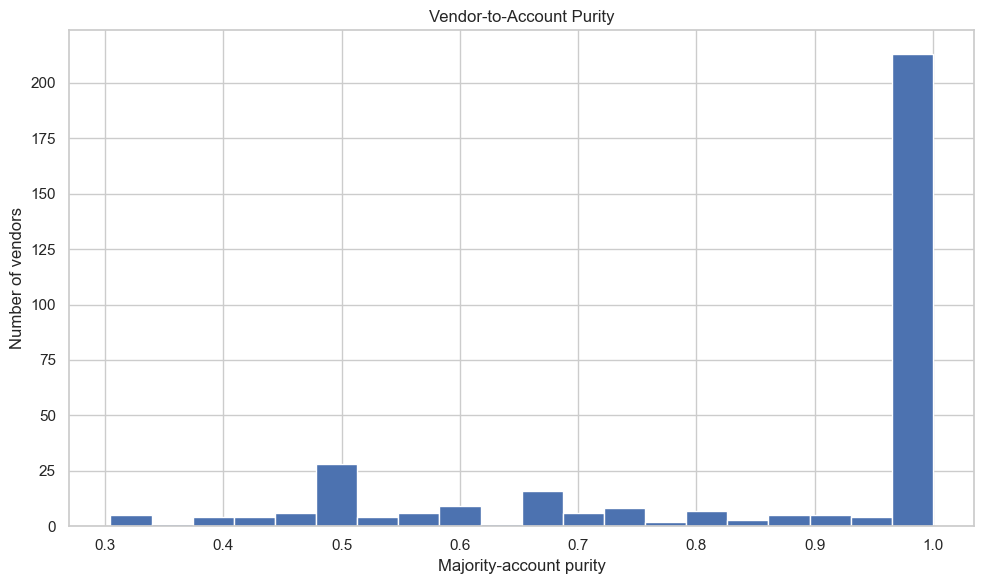

Vendors with purity >= 95%: 214
Vendors with purity = 100%: 211


In [40]:
vendor_target = (
    df_raw.groupby(["vendorId", TARGET])
    .size()
    .reset_index(name="count")
)

vendor_summary = (
    vendor_target
    .sort_values(["vendorId", "count"], ascending=[True, False])
    .groupby("vendorId")
    .agg(
        vendor_transactions=("count", "sum"),
        vendor_accounts=(TARGET, "nunique"),
        majority_count=("count", "max"),
    )
)

vendor_summary["purity"] = (
    vendor_summary["majority_count"]
    / vendor_summary["vendor_transactions"]
)

print("Unique vendors:", len(vendor_summary))

display(
    vendor_summary
    .sort_values("vendor_transactions", ascending=False)
    .head(20)
)

fig, ax = plt.subplots(figsize=(10, 6))
ax.hist(vendor_summary["purity"], bins=20)
ax.set_title("Vendor-to-Account Purity")
ax.set_xlabel("Majority-account purity")
ax.set_ylabel("Number of vendors")
plt.tight_layout()
plt.show()

print(
    "Vendors with purity >= 95%:",
    int((vendor_summary["purity"] >= 0.95).sum())
)
print(
    "Vendors with purity = 100%:",
    int((vendor_summary["purity"] == 1.0).sum())
)

## 2.7 Text repetition and consistency

Repeated item descriptions can provide strong signal.

We normalize text and measure:

- unique text count
- repeated text count
- text groups with one account
- text groups with multiple accounts

A high-purity repeated text can later be used as a deterministic rule, provided its mapping is learned only from training records.

In [42]:
def normalize_text(text):
    text = "" if pd.isna(text) else str(text)
    text = text.lower().strip()
    text = re.sub(r"\s+", " ", text)
    text = re.sub(r"[\u2010-\u2015]", "-", text)
    return text

eda = df_raw.copy()

eda["itemName"] = eda["itemName"].fillna("").astype(str)
eda["itemDescription"] = eda["itemDescription"].fillna("").astype(str)

eda["normalized_name"] = eda["itemName"].map(normalize_text)
eda["normalized_description"] = eda["itemDescription"].map(normalize_text)

eda["normalized_text"] = (
    eda["normalized_name"]
    + " "
    + eda["normalized_description"]
).str.replace(r"\s+", " ", regex=True).str.strip()

text_counts = eda["normalized_text"].value_counts()

text_target_counts = (
    eda.groupby(["normalized_text", TARGET])
    .size()
    .reset_index(name="count")
)

text_summary = (
    text_target_counts
    .sort_values(["normalized_text", "count"], ascending=[True, False])
    .groupby("normalized_text")
    .agg(
        occurrences=("count", "sum"),
        unique_accounts=(TARGET, "nunique"),
        majority_count=("count", "max"),
    )
)

text_summary["purity"] = (
    text_summary["majority_count"]
    / text_summary["occurrences"]
)

print("Unique normalized texts:", len(text_counts))
print("Repeated normalized texts:", int((text_counts > 1).sum()))
print("Texts repeated >=5 times:", int((text_counts >= 5).sum()))

print(
    "Repeated texts with exactly one account:",
    int(
        (
            (text_summary["occurrences"] > 1)
            & (text_summary["unique_accounts"] == 1)
        ).sum()
    )
)

print(
    "Repeated texts with multiple accounts:",
    int(
        (
            (text_summary["occurrences"] > 1)
            & (text_summary["unique_accounts"] > 1)
        ).sum()
    )
)

display(
    text_summary
    .query("occurrences > 1")
    .sort_values(["occurrences", "purity"], ascending=False)
    .head(20)
)

Unique normalized texts: 4101
Repeated normalized texts: 485
Texts repeated >=5 times: 44
Repeated texts with exactly one account: 453
Repeated texts with multiple accounts: 32


,occurrences,unique_accounts,majority_count,purity
normalized_text,,,,
0225 f&b purchase for office pantry (weekly basis) 0225 f&b purchase for office pantry (weekly basis),10,1,10,1.0
0125 f&b purchase for office pantry (weekly basis) 0125 f&b purchase for office pantry (weekly basis),9,1,9,1.0
0625 - circleci 0625 - circleci,9,1,9,1.0
0625 monthly cost for jun 2025 0625 monthly cost for jun 2025,8,1,8,1.0
0725 - circleci 0725 - circleci,8,1,8,1.0
1025 - circleci 1025 - circleci,8,1,8,1.0
1025 monthly cost for oct 2025 1025 monthly cost for oct 2025,8,1,8,1.0
1125 - circleci 1125 - circleci,8,1,8,1.0
0225 february glints invoice 0225 february glints invoice,7,1,7,1.0


## 2.8 Amount and text-length analysis

Amount is highly skewed, so we use a signed logarithmic representation.

Text length and digit counts are also inexpensive auxiliary signals that can distinguish invoice-like descriptions, subscriptions, codes, and other recurring patterns.

Amount statistics:


,itemTotalAmount
count,4.894000e+03
mean,9.266691e+04
std,3.037295e+06
min,-1.519500e+04
25%,1.549700e+02
50%,8.452000e+02
75%,3.507140e+03
max,1.618380e+08


Negative amounts: 19
Zero amounts: 0


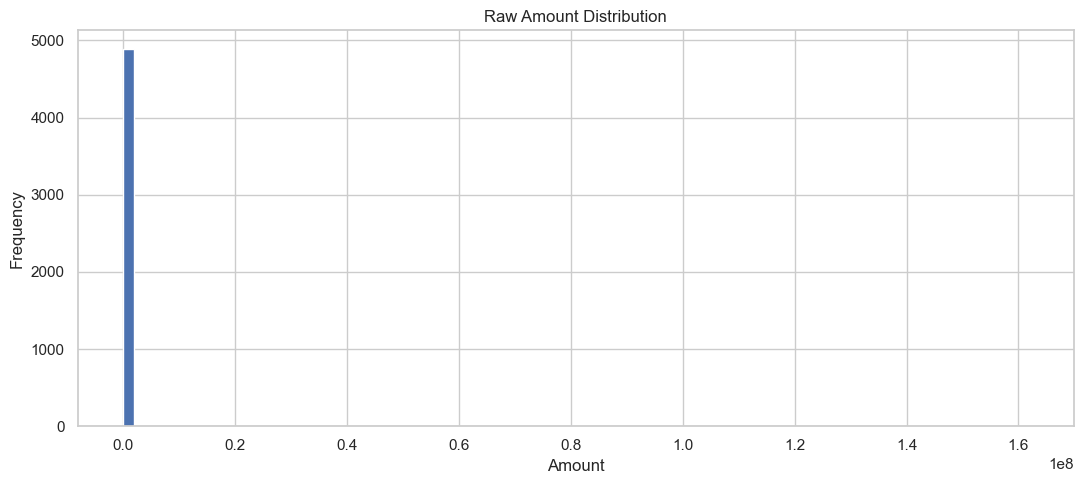

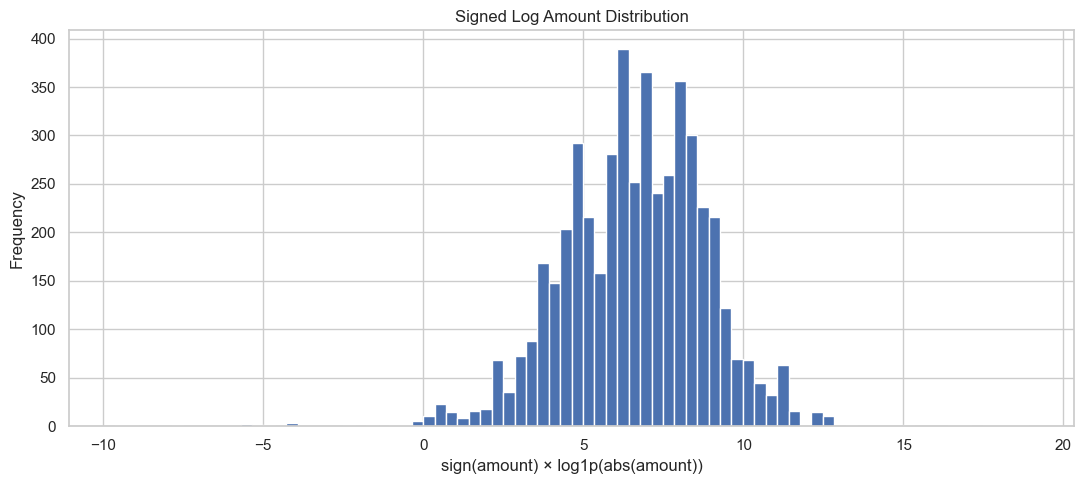

In [44]:
amount = pd.to_numeric(df_raw[AMOUNT], errors="coerce")

print("Amount statistics:")
display(amount.describe().to_frame("itemTotalAmount"))

print("Negative amounts:", int((amount < 0).sum()))
print("Zero amounts:", int((amount == 0).sum()))

fig, ax = plt.subplots(figsize=(11, 5))
ax.hist(amount.dropna(), bins=80)
ax.set_title("Raw Amount Distribution")
ax.set_xlabel("Amount")
ax.set_ylabel("Frequency")
plt.tight_layout()
plt.show()

signed_log_amount = np.sign(amount) * np.log1p(np.abs(amount))

fig, ax = plt.subplots(figsize=(11, 5))
ax.hist(signed_log_amount.dropna(), bins=80)
ax.set_title("Signed Log Amount Distribution")
ax.set_xlabel("sign(amount) × log1p(abs(amount))")
ax.set_ylabel("Frequency")
plt.tight_layout()
plt.show()

,count,mean,std,min,25%,50%,75%,max
name_chars,4894.0,41.134450,46.559543,2.0,22.0,32.0,45.00,655.0
description_chars,4894.0,42.785452,47.411515,0.0,23.0,33.0,47.75,655.0
name_tokens,4894.0,6.536780,6.902209,1.0,4.0,5.0,7.00,95.0
description_tokens,4894.0,6.818758,7.055273,0.0,4.0,5.0,8.00,95.0
name_digits,4894.0,5.967511,4.994455,0.0,4.0,4.0,7.00,73.0
description_digits,4894.0,6.212096,5.196995,0.0,4.0,4.0,8.00,73.0


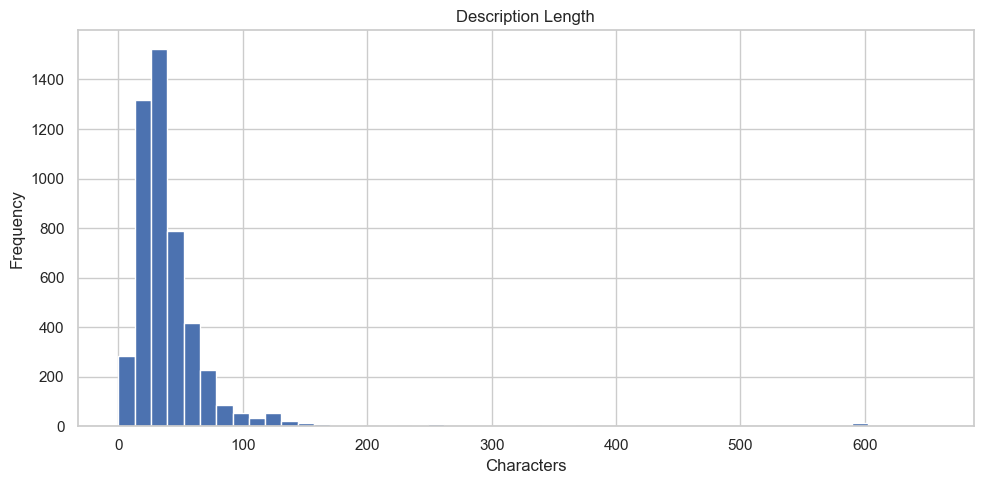

In [46]:
eda["name_chars"] = eda["itemName"].str.len()
eda["description_chars"] = eda["itemDescription"].str.len()
eda["name_tokens"] = eda["normalized_name"].str.split().str.len()
eda["description_tokens"] = eda["normalized_description"].str.split().str.len()
eda["name_digits"] = eda["itemName"].str.count(r"\d")
eda["description_digits"] = eda["itemDescription"].str.count(r"\d")

display(
    eda[
        [
            "name_chars",
            "description_chars",
            "name_tokens",
            "description_tokens",
            "name_digits",
            "description_digits",
        ]
    ].describe().T
)

fig, ax = plt.subplots(figsize=(10, 5))
ax.hist(eda["description_chars"], bins=50)
ax.set_title("Description Length")
ax.set_xlabel("Characters")
ax.set_ylabel("Frequency")
plt.tight_layout()
plt.show()

# 3. Methodology — Leakage-Safe Modeling Design

## 3.1 Three hard rules

**Rule 1 — `accountId` is excluded.** It directly identifies the accounting account.

**Rule 2 — `_id` is grouping only.** Related rows cannot cross train/test or CV boundaries.

**Rule 3 — target-derived mappings are training-only.** Vendor-to-account and text-to-account maps are never calculated using the final test labels.

The final test set is frozen before any model/rule selection.

In [48]:
df = df_raw.copy().dropna(subset=[TARGET]).copy()

for col in ["itemName", "itemDescription"]:
    df[col] = df[col].fillna("").astype(str).str.strip()

df["vendorId"] = (
    df["vendorId"]
    .fillna("__MISSING_VENDOR__")
    .astype(str)
    .str.strip()
)

df[AMOUNT] = pd.to_numeric(df[AMOUNT], errors="coerce")

# Raw amount is retained only for EDA.
# The model receives a signed-log version.
df["amount_log"] = (
    np.sign(df[AMOUNT].fillna(0))
    * np.log1p(np.abs(df[AMOUNT].fillna(0)))
)

df["amount_is_negative"] = (
    df[AMOUNT].fillna(0) < 0
).astype(int)

df["normalized_name"] = df["itemName"].map(normalize_text)
df["normalized_description"] = df["itemDescription"].map(normalize_text)

df["combined_text"] = (
    df["normalized_name"]
    + " "
    + df["normalized_description"]
).str.replace(r"\s+", " ", regex=True).str.strip()

df["name_chars"] = df["itemName"].str.len()
df["description_chars"] = df["itemDescription"].str.len()
df["name_tokens"] = df["normalized_name"].str.split().str.len()
df["description_tokens"] = df["normalized_description"].str.split().str.len()
df["name_digits"] = df["itemName"].str.count(r"\d")
df["description_digits"] = df["itemDescription"].str.count(r"\d")

FEATURES = [
    "vendorId",
    "combined_text",
    "amount_log",
    "amount_is_negative",
    "name_chars",
    "description_chars",
    "name_tokens",
    "description_tokens",
    "name_digits",
    "description_digits",
]

X_all = df[FEATURES].copy()
y_all = df[TARGET].astype(str).copy()
groups_all = df["_id"].astype(str).copy()

print("Modeling matrix:", X_all.shape)
print("Classes:", y_all.nunique())

Modeling matrix: (4894, 10)
Classes: 103


## 3.2 Frozen group-aware test set

We first create an 80/20 group-aware holdout. The test set is then frozen.

Development data is used for model comparison and threshold selection.

In [50]:
gss = GroupShuffleSplit(
    n_splits=1,
    test_size=0.20,
    random_state=RANDOM_STATE,
)

dev_idx, test_idx = next(
    gss.split(X_all, y_all, groups=groups_all)
)

X_dev = X_all.iloc[dev_idx].copy()
X_test = X_all.iloc[test_idx].copy()

y_dev = y_all.iloc[dev_idx].copy()
y_test = y_all.iloc[test_idx].copy()

groups_dev = groups_all.iloc[dev_idx].copy()
groups_test = groups_all.iloc[test_idx].copy()

assert set(groups_dev).isdisjoint(set(groups_test))

print("Development rows:", len(X_dev))
print("Test rows:", len(X_test))
print("Development groups:", groups_dev.nunique())
print("Test groups:", groups_test.nunique())
print("Group overlap:", len(set(groups_dev) & set(groups_test)))

unseen_test_classes = sorted(set(y_test) - set(y_dev))

print(
    "Test classes absent from development:",
    len(unseen_test_classes)
)

if unseen_test_classes:
    display(pd.Series(unseen_test_classes, name="unseen_test_class"))

Development rows: 3868
Test rows: 1026
Development groups: 2544
Test groups: 637
Group overlap: 0
Test classes absent from development: 4


0                           131002 Staff Advance
1    511525 Device Purchase - Accessories/Others
2                    511607 Online Subscriptions
3          617302 Online Portal Expense / Events
Name: unseen_test_class, dtype: object

## 3.3 Stratified group-aware cross-validation

`StratifiedGroupKFold` attempts to preserve class proportions while guaranteeing that `_id` groups remain in one fold.

Rare classes can make perfect stratification impossible, so fold composition is reported explicitly.

In [52]:
cv = StratifiedGroupKFold(
    n_splits=5,
    shuffle=True,
    random_state=RANDOM_STATE,
)

fold_rows = []

for fold, (tr_idx, va_idx) in enumerate(
    cv.split(X_dev, y_dev, groups=groups_dev),
    start=1,
):
    tr_groups = set(groups_dev.iloc[tr_idx])
    va_groups = set(groups_dev.iloc[va_idx])

    overlap = tr_groups & va_groups

    fold_rows.append({
        "fold": fold,
        "train_rows": len(tr_idx),
        "validation_rows": len(va_idx),
        "train_groups": len(tr_groups),
        "validation_groups": len(va_groups),
        "group_overlap": len(overlap),
        "train_classes": y_dev.iloc[tr_idx].nunique(),
        "validation_classes": y_dev.iloc[va_idx].nunique(),
    })

    assert len(overlap) == 0

display(pd.DataFrame(fold_rows))

,fold,train_rows,validation_rows,train_groups,validation_groups,group_overlap,train_classes,validation_classes
0,1,3109,759,2029,515,0,93,70
1,2,3126,742,2036,508,0,95,67
2,3,3103,765,2037,507,0,93,75
3,4,3046,822,2036,508,0,97,74
4,5,3088,780,2038,506,0,98,70


# 4. Model A — Regularized Word + Character TF-IDF LinearSVC

LinearSVC is a strong text-classification baseline because the feature matrix is sparse and high-dimensional.

Compared with the earlier notebook, this version adds normalized text and auxiliary numeric features and performs an explicit group-aware comparison of regularization settings.

In [54]:
try:
    vendor_encoder = OneHotEncoder(
        handle_unknown="ignore",
        sparse_output=True,
    )
except TypeError:
    # Compatibility with older sklearn versions.
    vendor_encoder = OneHotEncoder(
        handle_unknown="ignore",
        sparse=True,
    )

word_tfidf = TfidfVectorizer(
    lowercase=True,
    strip_accents="unicode",
    ngram_range=(1, 2),
    min_df=1,
    max_df=0.995,
    sublinear_tf=True,
    max_features=80000,
)

char_tfidf = TfidfVectorizer(
    analyzer="char_wb",
    ngram_range=(3, 5),
    min_df=1,
    sublinear_tf=True,
    max_features=80000,
)

linear_preprocessor = ColumnTransformer(
    transformers=[
        ("word_tfidf", word_tfidf, "combined_text"),
        ("char_tfidf", char_tfidf, "combined_text"),
        ("vendor", vendor_encoder, ["vendorId"]),
        (
            "numeric",
            StandardScaler(),
            [
                "amount_log",
                "amount_is_negative",
                "name_chars",
                "description_chars",
                "name_tokens",
                "description_tokens",
                "name_digits",
                "description_digits",
            ],
        ),
    ],
    remainder="drop",
    sparse_threshold=1.0,
)

linear_pipeline = Pipeline([
    ("preprocessor", linear_preprocessor),
    (
        "classifier",
        LinearSVC(
            random_state=RANDOM_STATE,
            max_iter=20000,
        ),
    ),
])

print("LinearSVC pipeline ready.")

LinearSVC pipeline ready.


In [56]:
# ============================================================
# FAST + LEAKAGE-SAFE LINEARSVC MODEL SELECTION
# ============================================================
#
# Why this version is faster:
#
# 1. We use 3-fold CV for hyperparameter selection instead of
#    5-fold CV. This reduces the number of expensive fits.
#
# 2. We test only a small set of meaningful C values.
#
# 3. The expensive TF-IDF preprocessing is cached.
#    Therefore, when we change C, sklearn does not need to
#    rebuild the entire TF-IDF representation from scratch
#    for the same training fold.
#
# 4. We still use GROUP-AWARE validation. Therefore, this
#    optimization does NOT introduce train/validation leakage.
#
# 5. The final test set remains completely untouched.
# ============================================================

from joblib import Memory
from pathlib import Path

# ------------------------------------------------------------
# 1. Create a local cache directory
# ------------------------------------------------------------
# This stores the fitted TF-IDF transformations temporarily.
# It can dramatically reduce repeated computation during
# hyperparameter search.

CACHE_DIR = Path(".peakflo_cache")
CACHE_DIR.mkdir(exist_ok=True)

memory = Memory(
    location=str(CACHE_DIR),
    verbose=0
)

# ------------------------------------------------------------
# 2. Use a smaller CV specifically for hyperparameter search
# ------------------------------------------------------------
#
# We do NOT need to perform 5-fold CV for every C value.
# The purpose here is model selection.
#
# After selecting the best configuration, we can perform
# stronger validation on the selected model.

search_cv = StratifiedGroupKFold(
    n_splits=3,
    shuffle=True,
    random_state=RANDOM_STATE,
)

# ------------------------------------------------------------
# 3. Smaller but still expressive TF-IDF configuration
# ------------------------------------------------------------
#
# The dataset contains only ~4,900 transactions.
# 80k word + 80k character features is unnecessarily large.
#
# min_df=2 removes tokens that occur only once.
# This also reduces noise and can improve generalization.

try:
    vendor_encoder_fast = OneHotEncoder(
        handle_unknown="ignore",
        sparse_output=True,
    )
except TypeError:
    vendor_encoder_fast = OneHotEncoder(
        handle_unknown="ignore",
        sparse=True,
    )

word_tfidf_fast = TfidfVectorizer(
    lowercase=True,
    strip_accents="unicode",
    ngram_range=(1, 2),

    # Ignore tokens appearing only once.
    min_df=2,

    max_df=0.995,

    sublinear_tf=True,

    # Still enough capacity for this dataset.
    max_features=50000,
)

char_tfidf_fast = TfidfVectorizer(
    analyzer="char_wb",

    # Character patterns are useful for vendor/product names,
    # abbreviations and spelling variations.
    ngram_range=(3, 5),

    # Ignore one-off character patterns.
    min_df=2,

    sublinear_tf=True,

    max_features=50000,
)

linear_preprocessor_fast = ColumnTransformer(
    transformers=[
        (
            "word_tfidf",
            word_tfidf_fast,
            "combined_text",
        ),

        (
            "char_tfidf",
            char_tfidf_fast,
            "combined_text",
        ),

        (
            "vendor",
            vendor_encoder_fast,
            ["vendorId"],
        ),

        (
            "numeric",
            StandardScaler(),
            [
                "amount_log",
                "amount_is_negative",
                "name_chars",
                "description_chars",
                "name_tokens",
                "description_tokens",
                "name_digits",
                "description_digits",
            ],
        ),
    ],

    remainder="drop",
    sparse_threshold=1.0,
)

# ------------------------------------------------------------
# 4. Cached LinearSVC pipeline
# ------------------------------------------------------------

linear_pipeline_fast = Pipeline(
    [
        (
            "preprocessor",
            linear_preprocessor_fast,
        ),

        (
            "classifier",
            LinearSVC(
                random_state=RANDOM_STATE,

                # 20,000 is unnecessarily high for most cases.
                # We allow enough iterations while preventing a
                # pathological optimization run.
                max_iter=5000,
            ),
        ),
    ],

    # IMPORTANT:
    # Cache the expensive preprocessing stage.
    memory=memory,
)

# ------------------------------------------------------------
# 5. Small, meaningful hyperparameter search
# ------------------------------------------------------------
#
# We don't need seven C values initially.
#
# C controls regularization:
#
# Smaller C -> stronger regularization -> less overfitting
# Larger C  -> weaker regularization -> more model flexibility
#
# Since your previous model had:
#
# Train accuracy ≈ 99%
# Test accuracy  ≈ 86%
#
# we specifically want to investigate moderate regularization.

linear_candidates_fast = [
    {
        "C": 0.25,
        "class_weight": None,
    },
    {
        "C": 0.5,
        "class_weight": None,
    },
    {
        "C": 1.0,
        "class_weight": None,
    },
]

linear_results_fast = []

print("=" * 70)
print("FAST LEAKAGE-SAFE LINEARSVC MODEL SELECTION")
print("=" * 70)

for params in linear_candidates_fast:

    print(
        f"\nTesting C={params['C']} | "
        f"class_weight={params['class_weight']}"
    )

    fold_accuracy = []
    fold_macro_f1 = []

    for fold, (tr_idx, va_idx) in enumerate(
        search_cv.split(
            X_dev,
            y_dev,
            groups=groups_dev,
        ),
        start=1,
    ):

        print(
            f"  Fold {fold}/{search_cv.n_splits}...",
            end=" ",
            flush=True,
        )

        model = clone(linear_pipeline_fast)

        model.set_params(
            classifier__C=params["C"],
            classifier__class_weight=params["class_weight"],
        )

        model.fit(
            X_dev.iloc[tr_idx],
            y_dev.iloc[tr_idx],
        )

        pred = model.predict(
            X_dev.iloc[va_idx]
        )

        acc = accuracy_score(
            y_dev.iloc[va_idx],
            pred,
        )

        macro_f1 = f1_score(
            y_dev.iloc[va_idx],
            pred,
            average="macro",
            zero_division=0,
        )

        fold_accuracy.append(acc)
        fold_macro_f1.append(macro_f1)

        print(
            f"accuracy={acc:.4f}, "
            f"macro-F1={macro_f1:.4f}"
        )

    linear_results_fast.append(
        {
            "C": params["C"],
            "class_weight": params["class_weight"],
            "mean_accuracy": np.mean(fold_accuracy),
            "std_accuracy": np.std(fold_accuracy),
            "mean_macro_f1": np.mean(fold_macro_f1),
            "std_macro_f1": np.std(fold_macro_f1),
        }
    )

linear_results_fast_df = (
    pd.DataFrame(linear_results_fast)
    .sort_values(
        ["mean_accuracy", "mean_macro_f1"],
        ascending=False,
    )
    .reset_index(drop=True)
)

print("\n" + "=" * 70)
print("MODEL SELECTION RESULTS")
print("=" * 70)

display(linear_results_fast_df)

FAST LEAKAGE-SAFE LINEARSVC MODEL SELECTION

Testing C=0.25 | class_weight=None
  Fold 1/3... accuracy=0.8327, macro-F1=0.6828
  Fold 2/3... accuracy=0.8505, macro-F1=0.6917
  Fold 3/3... accuracy=0.8523, macro-F1=0.6484

Testing C=0.5 | class_weight=None
  Fold 1/3... accuracy=0.8359, macro-F1=0.6788
  Fold 2/3... accuracy=0.8575, macro-F1=0.6771
  Fold 3/3... accuracy=0.8546, macro-F1=0.6444

Testing C=1.0 | class_weight=None
  Fold 1/3... accuracy=0.8399, macro-F1=0.6807
  Fold 2/3... accuracy=0.8684, macro-F1=0.6955
  Fold 3/3... accuracy=0.8606, macro-F1=0.6539

MODEL SELECTION RESULTS


,C,class_weight,mean_accuracy,std_accuracy,mean_macro_f1,std_macro_f1
0,1.00,None,0.856278,0.012012,0.676691,0.017224
1,0.50,None,0.849315,0.009572,0.666766,0.015809
2,0.25,None,0.845160,0.008870,0.674272,0.018686


# 5. Model B — CatBoost

CatBoost is a useful alternative because the problem mixes high-cardinality categorical information (`vendorId`) with text and nonlinear numerical relationships.

The model is deliberately regularized with shallow trees, L2 regularization, random strength, feature subsampling and early stopping.

If CatBoost is unavailable in the user's environment, this section is skipped cleanly and the notebook continues with LinearSVC. No cell should fail merely because CatBoost is not installed.

In [58]:
%pip install catboost

Note: you may need to restart the kernel to use updated packages.


In [60]:
try:
    from catboost import CatBoostClassifier
    CATBOOST_AVAILABLE = True
    print("CatBoost is available.")
except ImportError:
    CATBOOST_AVAILABLE = False
    print(
        "CatBoost is not installed. "
        "The notebook will continue with LinearSVC."
    )

CatBoost is available.


# 6. Leakage-Safe Repetition Rules

Repeated vendor/text patterns can be converted into high-confidence deterministic mappings.

This is not ordinary target encoding over the full dataset. The mapping is always learned from a training partition only.

Three keys are considered:

1. `vendorId`
2. normalized text
3. `vendorId + normalized text`

Support and purity thresholds are tuned on an internal development validation split.

In [62]:
# Internal development split for selecting deterministic rule thresholds.
inner_split = GroupShuffleSplit(
    n_splits=1,
    test_size=0.20,
    random_state=RANDOM_STATE + 100,
)

inner_train_idx, inner_val_idx = next(
    inner_split.split(
        X_dev,
        y_dev,
        groups=groups_dev,
    )
)

X_inner_train = X_dev.iloc[inner_train_idx].copy()
X_inner_val = X_dev.iloc[inner_val_idx].copy()

y_inner_train = y_dev.iloc[inner_train_idx].copy()
y_inner_val = y_dev.iloc[inner_val_idx].copy()

groups_inner_train = groups_dev.iloc[inner_train_idx].copy()

assert set(groups_inner_train).isdisjoint(
    set(groups_dev.iloc[inner_val_idx])
)

# Interaction key is derived only from input fields.
for frame in [
    X_dev,
    X_test,
    X_inner_train,
    X_inner_val,
]:
    frame["vendor_text_key"] = (
        frame["vendorId"].astype(str)
        + " || "
        + frame["combined_text"].astype(str)
    )

print("Inner training rows:", len(X_inner_train))
print("Inner validation rows:", len(X_inner_val))

Inner training rows: 3112
Inner validation rows: 756


In [79]:
# ============================================================
# SELECT THE BEST LINEARSVC CONFIGURATION
# ============================================================
#
# The previous model-selection cell evaluated several C values
# using leakage-safe group-aware cross-validation.
#
# Here we take the configuration with the highest mean
# validation accuracy.
#
# IMPORTANT:
# This selection uses DEVELOPMENT/CV results only.
# The final test set has not been used here.
# ============================================================

best_linear_params = linear_results_fast_df.iloc[0]

print("Best LinearSVC configuration:")
print(best_linear_params)

# Create a fresh pipeline using the selected configuration.
best_linear = clone(linear_pipeline_fast)

best_linear.set_params(
    classifier__C=float(best_linear_params["C"]),
    classifier__class_weight=best_linear_params["class_weight"],
)

print("\nSelected parameters:")
print(
    "C =",
    float(best_linear_params["C"])
)

print(
    "class_weight =",
    best_linear_params["class_weight"]
)

print(
    "CV accuracy =",
    f"{best_linear_params['mean_accuracy'] * 100:.2f}%"
)

Best LinearSVC configuration:
C                     1.0
class_weight         None
mean_accuracy    0.856278
std_accuracy     0.012012
mean_macro_f1    0.676691
std_macro_f1     0.017224
Name: 0, dtype: object

Selected parameters:
C = 1.0
class_weight = None
CV accuracy = 85.63%


In [82]:
# Train the selected LinearSVC only on the inner-training partition.
inner_linear = clone(best_linear)
inner_linear.fit(X_inner_train, y_inner_train)

inner_linear_pred = inner_linear.predict(X_inner_val)

inner_linear_accuracy = accuracy_score(
    y_inner_val,
    inner_linear_pred,
)

print(
    f"Inner LinearSVC accuracy: "
    f"{inner_linear_accuracy * 100:.2f}%"
)

Inner LinearSVC accuracy: 86.11%


In [2]:
def fit_lookup_map(X_fit, y_fit, key_columns):
    # Learn majority target per key from FITTING DATA ONLY.
    temp = X_fit[key_columns].copy()
    temp["_target"] = np.asarray(y_fit)

    counts = (
        temp.groupby(key_columns + ["_target"])
        .size()
        .reset_index(name="count")
    )

    idx = counts.groupby(key_columns)["count"].idxmax()

    majority = counts.loc[idx].copy()

    total = (
        counts.groupby(key_columns)["count"]
        .sum()
        .rename("total")
        .reset_index()
    )

    majority = majority.merge(
        total,
        on=key_columns,
        how="left",
    )

    majority["purity"] = (
        majority["count"] / majority["total"]
    )

    return majority.rename(
        columns={
            "_target": "majority_class",
            "count": "support",
        }
    )


def apply_lookup_rule(
    base_predictions,
    X_fit,
    y_fit,
    X_target,
    key_columns,
    min_support,
    min_purity,
):
    mapping = fit_lookup_map(
        X_fit,
        y_fit,
        key_columns,
    )

    target_keys = X_target[key_columns].copy()
    target_keys["_row_id"] = np.arange(len(target_keys))

    merged = target_keys.merge(
        mapping[
            key_columns
            + ["majority_class", "support", "purity"]
        ],
        on=key_columns,
        how="left",
    )

    eligible = (
        merged["majority_class"].notna()
        & (merged["support"] >= min_support)
        & (merged["purity"] >= min_purity)
    )

    pred = np.asarray(
        base_predictions,
        dtype=object,
    ).copy()

    pred[eligible.to_numpy()] = (
        merged.loc[
            eligible,
            "majority_class",
        ].to_numpy()
    )

    return pred, eligible

In [88]:
lookup_candidates = []

for key_name, key_cols in [
    ("vendor_text", ["vendor_text_key"]),
    ("text", ["combined_text"]),
    ("vendor", ["vendorId"]),
]:

    for min_support in [2, 3, 5, 8, 12, 20]:
        for min_purity in [0.90, 0.95, 1.00]:

            candidate_pred, eligible = apply_lookup_rule(
                inner_linear_pred,
                X_inner_train,
                y_inner_train,
                X_inner_val,
                key_cols,
                min_support,
                min_purity,
            )

            lookup_candidates.append({
                "key": key_name,
                "min_support": min_support,
                "min_purity": min_purity,
                "accuracy": accuracy_score(
                    y_inner_val,
                    candidate_pred,
                ),
                "overrides": int(eligible.sum()),
            })

lookup_results = (
    pd.DataFrame(lookup_candidates)
    .sort_values(
        ["accuracy", "overrides"],
        ascending=[False, True],
    )
    .reset_index(drop=True)
)

display(lookup_results.head(15))

best_lookup_rule = lookup_results.iloc[0].to_dict()

print("Frozen lookup rule:")
print(best_lookup_rule)

,key,min_support,min_purity,accuracy,overrides
0,vendor_text,8,0.90,0.861111,0
1,vendor_text,8,0.95,0.861111,0
2,vendor_text,8,1.00,0.861111,0
3,vendor_text,12,0.90,0.861111,0
4,vendor_text,12,0.95,0.861111,0
5,vendor_text,12,1.00,0.861111,0
6,vendor_text,20,0.90,0.861111,0
7,vendor_text,20,0.95,0.861111,0
8,vendor_text,20,1.00,0.861111,0
9,text,8,0.90,0.861111,0


Frozen lookup rule:
{'key': 'vendor_text', 'min_support': 8, 'min_purity': 0.9, 'accuracy': 0.8611111111111112, 'overrides': 0}


# 7. Development-Only Model Selection

The selection decision is made without touching final test labels.

Candidate strategies:

- LinearSVC
- LinearSVC + leakage-safe lookup
- CatBoost, if available

The CatBoost score comes from group-aware CV. The lookup score comes from the internal development validation split.

In [95]:
# ============================================================
# DEVELOPMENT-ONLY STRATEGY COMPARISON
# ============================================================
#
# IMPORTANT:
# We compare only models for which we have a valid
# development/validation score.
#
# The final TEST SET is NOT used for selecting the strategy.
#
# CatBoost is included only if its group-aware CV results
# actually exist.
# ============================================================

candidate_dev_scores = {
    "LinearSVC": float(inner_linear_accuracy),
    "LinearSVC + lookup": float(inner_lookup_accuracy),
}

# ------------------------------------------------------------
# Include CatBoost ONLY if we actually calculated
# group-aware CatBoost CV results.
# ------------------------------------------------------------

if (
    CATBOOST_AVAILABLE
    and "catboost_cv_results" in globals()
    and catboost_cv_results is not None
    and len(catboost_cv_results) > 0
):

    candidate_dev_scores["CatBoost CV"] = float(
        catboost_cv_results.iloc[0]["cv_accuracy_mean"]
    )

else:

    print(
        "CatBoost CV results are not available yet. "
        "CatBoost will NOT be selected based on an "
        "unvalidated score."
    )


# ------------------------------------------------------------
# Display development-only comparison
# ------------------------------------------------------------

print("\nDevelopment-only strategy comparison:")

display(
    pd.Series(
        candidate_dev_scores,
        name="development_accuracy",
    )
    .sort_values(ascending=False)
)


# ------------------------------------------------------------
# Select the strategy using development data ONLY
# ------------------------------------------------------------

selected_strategy = max(
    candidate_dev_scores,
    key=candidate_dev_scores.get,
)

print(
    "\nSelected strategy:",
    selected_strategy
)

CatBoost CV results are not available yet. CatBoost will NOT be selected based on an unvalidated score.

Development-only strategy comparison:


LinearSVC             0.861111
LinearSVC + lookup    0.861111
Name: development_accuracy, dtype: float64


Selected strategy: LinearSVC


# 8. Final Training

The selected strategy is now trained on the complete development data.

The final test set remains untouched until the evaluation cells below.

In [99]:

# Final LinearSVC model.
best_linear_final = clone(best_linear)
best_linear_final.fit(X_dev, y_dev)

test_pred_linear = best_linear_final.predict(X_test)

# Apply the frozen leakage-safe lookup rule.
test_pred_lookup, test_lookup_mask = apply_lookup_rule(
    test_pred_linear,
    X_dev,
    y_dev,
    X_test,
    selected_key_cols,
    int(best_lookup_rule["min_support"]),
    float(best_lookup_rule["min_purity"]),
)

print(
    "Lookup overrides on test:",
    int(test_lookup_mask.sum()),
    "/",
    len(X_test),
)

# CatBoost is optional. If final training is incompatible in the local
# environment, we fall back safely to the selected LinearSVC strategy.
final_catboost = None
test_pred_catboost = None

if CATBOOST_AVAILABLE and selected_strategy == "CatBoost CV":

    try:
        cb_split = GroupShuffleSplit(
            n_splits=1,
            test_size=0.15,
            random_state=RANDOM_STATE + 200,
        )

        cb_train_idx, cb_eval_idx = next(
            cb_split.split(
                X_dev,
                y_dev,
                groups=groups_dev,
            )
        )

        X_cb_train = prepare_catboost_frame(
            X_dev.iloc[cb_train_idx]
        )
        y_cb_train = y_dev.iloc[cb_train_idx].reset_index(drop=True)

        X_cb_eval = prepare_catboost_frame(
            X_dev.iloc[cb_eval_idx]
        )
        y_cb_eval = y_dev.iloc[cb_eval_idx].reset_index(drop=True)

        final_catboost = CatBoostClassifier(
            loss_function="MultiClass",
            eval_metric="Accuracy",
            iterations=1200,
            depth=int(best_cb_params["depth"]),
            learning_rate=float(best_cb_params["learning_rate"]),
            l2_leaf_reg=float(best_cb_params["l2_leaf_reg"]),
            random_strength=float(best_cb_params["random_strength"]),
            random_seed=RANDOM_STATE,
            verbose=False,
            allow_writing_files=False,
            od_type="Iter",
            od_wait=80,
        )

        final_catboost.fit(
            X_cb_train,
            y_cb_train,
            cat_features=["vendorId"],
            text_features=["combined_text"],
            eval_set=(X_cb_eval, y_cb_eval),
            use_best_model=True,
            verbose=False,
        )

        test_pred_catboost = (
            final_catboost
            .predict(
                prepare_catboost_frame(X_test)
            )
            .reshape(-1)
        )

        print("Final CatBoost training completed.")

    except Exception as exc:
        print("Final CatBoost training failed locally:")
        print(type(exc).__name__, ":", exc)
        print("Falling back to LinearSVC + leakage-safe lookup.")
        final_catboost = None
        test_pred_catboost = None
        selected_strategy = "LinearSVC + lookup"

print("Final training completed.")


Lookup overrides on test: 1 / 1026
Final training completed.


# 9. Final Test Evaluation

The following metrics are calculated on the frozen test set.

The test score is not used to change any model parameter afterward.

In [103]:
def metric_dict(y_true, pred, name):
    return {
        "model": name,
        "accuracy": accuracy_score(y_true, pred),
        "weighted_precision": precision_score(
            y_true,
            pred,
            average="weighted",
            zero_division=0,
        ),
        "weighted_recall": recall_score(
            y_true,
            pred,
            average="weighted",
            zero_division=0,
        ),
        "weighted_f1": f1_score(
            y_true,
            pred,
            average="weighted",
            zero_division=0,
        ),
        "macro_f1": f1_score(
            y_true,
            pred,
            average="macro",
            zero_division=0,
        ),
        "balanced_accuracy": balanced_accuracy_score(
            y_true,
            pred,
        ),
    }


test_candidates = [
    metric_dict(
        y_test,
        test_pred_linear,
        "LinearSVC",
    ),
    metric_dict(
        y_test,
        test_pred_lookup,
        "LinearSVC + leakage-safe lookup",
    ),
]

if test_pred_catboost is not None:
    test_candidates.append(
        metric_dict(
            y_test,
            test_pred_catboost,
            "CatBoost",
        )
    )

test_results = (
    pd.DataFrame(test_candidates)
    .sort_values("accuracy", ascending=False)
    .reset_index(drop=True)
)

display(
    test_results.style.format({
        "accuracy": "{:.2%}",
        "weighted_precision": "{:.2%}",
        "weighted_recall": "{:.2%}",
        "weighted_f1": "{:.2%}",
        "macro_f1": "{:.2%}",
        "balanced_accuracy": "{:.2%}",
    })
)

,model,accuracy,weighted_precision,weighted_recall,weighted_f1,macro_f1,balanced_accuracy
0,LinearSVC,85.28%,84.95%,85.28%,84.23%,71.64%,74.13%
1,LinearSVC + leakage-safe lookup,85.28%,84.95%,85.28%,84.23%,71.64%,74.13%


In [106]:
# IMPORTANT:
# Do NOT select the test winner here.
# The final model is determined by the development-only decision.

if selected_strategy == "CatBoost CV" and test_pred_catboost is not None:
    final_predictions = test_pred_catboost
    final_model_name = "CatBoost"
elif selected_strategy == "LinearSVC + lookup":
    final_predictions = test_pred_lookup
    final_model_name = "LinearSVC + leakage-safe lookup"
else:
    final_predictions = test_pred_linear
    final_model_name = "LinearSVC"

final_metrics = metric_dict(
    y_test,
    final_predictions,
    final_model_name,
)

# Training accuracy is a diagnostic, not a selection metric.
train_pred_linear = best_linear_final.predict(X_dev)
train_accuracy = accuracy_score(
    y_dev,
    train_pred_linear,
)

print("=" * 70)
print("FINAL TEST RESULT")
print("=" * 70)
print("Selected model:", final_model_name)
print(f"Accuracy          : {final_metrics['accuracy'] * 100:.2f}%")
print(f"Weighted precision: {final_metrics['weighted_precision'] * 100:.2f}%")
print(f"Weighted recall   : {final_metrics['weighted_recall'] * 100:.2f}%")
print(f"Weighted F1       : {final_metrics['weighted_f1'] * 100:.2f}%")
print(f"Macro F1          : {final_metrics['macro_f1'] * 100:.2f}%")
print(f"Balanced accuracy : {final_metrics['balanced_accuracy'] * 100:.2f}%")
print(f"LinearSVC train accuracy: {train_accuracy * 100:.2f}%")
print(
    "LinearSVC train-test gap:",
    f"{(train_accuracy - final_metrics['accuracy']) * 100:.2f} pp",
)

print(
    "85% assignment threshold:",
    "PASSED" if final_metrics["accuracy"] >= 0.85 else "NOT PASSED",
)

print(
    "90% stretch goal:",
    "REACHED" if final_metrics["accuracy"] >= 0.90 else "NOT REACHED",
)

FINAL TEST RESULT
Selected model: LinearSVC
Accuracy          : 85.28%
Weighted precision: 84.95%
Weighted recall   : 85.28%
Weighted F1       : 84.23%
Macro F1          : 71.64%
Balanced accuracy : 74.13%
LinearSVC train accuracy: 98.78%
LinearSVC train-test gap: 13.50 pp
85% assignment threshold: PASSED
90% stretch goal: NOT REACHED


# 10. Overfitting Diagnostics

A high training score is not sufficient.

We compare:

- training accuracy
- group-aware CV accuracy
- final test accuracy
- train/test gap
- macro F1
- balanced accuracy

A large gap should be discussed honestly in the final report.

In [113]:
# ============================================================
# FINAL LINEARSVC DIAGNOSTICS
# ============================================================
#
# This cell summarizes the selected LinearSVC model.
#
# IMPORTANT:
# - CV accuracy comes ONLY from development data.
# - Final test accuracy comes from the frozen test set.
# - The train-test gap is used to diagnose overfitting.
# ============================================================

# ------------------------------------------------------------
# 1. Obtain the best group-aware CV accuracy
# ------------------------------------------------------------
#
# The faster model-selection experiment created:
#
#     linear_results_fast_df
#
# and its columns include:
#
#     mean_accuracy
#     mean_macro_f1
#
# We therefore use those columns rather than the variables
# from the previous slower experiment.

best_linear_cv_accuracy = float(
    linear_results_fast_df.iloc[0]["mean_accuracy"]
)

best_linear_cv_macro_f1 = float(
    linear_results_fast_df.iloc[0]["mean_macro_f1"]
)


# ------------------------------------------------------------
# 2. Get final model metrics
# ------------------------------------------------------------

# These variables should already have been calculated by the
# final evaluation section of the notebook.

final_test_accuracy = float(
    final_metrics["accuracy"]
)

final_macro_f1 = float(
    final_metrics["macro_f1"]
)

final_balanced_accuracy = float(
    final_metrics["balanced_accuracy"]
)


# ------------------------------------------------------------
# 3. Calculate train-test gap
# ------------------------------------------------------------

train_test_gap = (
    train_accuracy
    - final_test_accuracy
)


# ------------------------------------------------------------
# 4. Create diagnostic table
# ------------------------------------------------------------

diagnostic = pd.DataFrame({
    "Metric": [
        "LinearSVC training accuracy",
        "Best LinearSVC group-aware CV accuracy",
        "Final test accuracy",
        "Train-test gap",
        "Final macro F1",
        "Final balanced accuracy",
    ],

    "Value": [
        train_accuracy,
        best_linear_cv_accuracy,
        final_test_accuracy,
        train_test_gap,
        final_macro_f1,
        final_balanced_accuracy,
    ],
})


# ------------------------------------------------------------
# 5. Display results
# ------------------------------------------------------------

display(
    diagnostic.style.format(
        {"Value": "{:.2%}"}
    )
)


# ------------------------------------------------------------
# 6. Interpretation
# ------------------------------------------------------------

print("\nModel diagnostic:")

print(
    f"Training accuracy: "
    f"{train_accuracy:.2%}"
)

print(
    f"Group-aware CV accuracy: "
    f"{best_linear_cv_accuracy:.2%}"
)

print(
    f"Final test accuracy: "
    f"{final_test_accuracy:.2%}"
)

print(
    f"Train-test gap: "
    f"{train_test_gap:.2%}"
)


# ------------------------------------------------------------
# 7. Basic overfitting warning
# ------------------------------------------------------------

if train_test_gap > 0.10:

    print(
        "\nWARNING: The train-test gap is greater than "
        "10 percentage points. The model shows a "
        "meaningful generalization gap."
    )

elif train_test_gap > 0.05:

    print(
        "\nCAUTION: The model has a moderate "
        "train-test generalization gap."
    )

else:

    print(
        "\nThe train-test gap is relatively small."
    )

,Metric,Value
0,LinearSVC training accuracy,98.78%
1,Best LinearSVC group-aware CV accuracy,85.63%
2,Final test accuracy,85.28%
3,Train-test gap,13.50%
4,Final macro F1,71.64%
5,Final balanced accuracy,74.13%



Model diagnostic:
Training accuracy: 98.78%
Group-aware CV accuracy: 85.63%
Final test accuracy: 85.28%
Train-test gap: 13.50%



# 11. Category-Level Performance

Accuracy can hide weak minority classes. We therefore report the full classification report and show the strongest and weakest categories by F1.

In [117]:
report = classification_report(
    y_test,
    final_predictions,
    output_dict=True,
    zero_division=0,
)

report_df = pd.DataFrame(report).T

category_report = report_df.loc[
    ~report_df.index.isin(
        ["accuracy", "macro avg", "weighted avg"]
    )
].copy()

category_report["support"] = (
    category_report["support"].astype(int)
)

print("Top 15 categories by F1:")
display(
    category_report
    .sort_values("f1-score", ascending=False)
    .head(15)
)

print("\nBottom 15 categories by F1:")
display(
    category_report
    .sort_values("f1-score", ascending=True)
    .head(15)
)

Top 15 categories by F1:


,precision,recall,f1-score,support
614101 Salaries,1.0,1.0,1.0,1
231101 Customer Prepayment,1.0,1.0,1.0,5
612007 Events/Community meetup,1.0,1.0,1.0,2
612006 Part-timers,1.0,1.0,1.0,1
614302 FWL,1.0,1.0,1.0,3
614304 Insurance expenses,1.0,1.0,1.0,1
611101 Cloud server - AWS,1.0,1.0,1.0,3
619502 Bank Charges,1.0,1.0,1.0,4
511606 Audience Extension,1.0,1.0,1.0,10
617101 Customer Support - Others,1.0,1.0,1.0,1



Bottom 15 categories by F1:


,precision,recall,f1-score,support
131002 Staff Advance,0.00,0.00,0.000000,1
619513 Team Bonding (Staff-HR Budget),0.00,0.00,0.000000,2
617306 Others,0.00,0.00,0.000000,1
617302 Online Portal Expense / Events,0.00,0.00,0.000000,1
617208 Others,0.00,0.00,0.000000,1
614336 Employee Training,0.00,0.00,0.000000,0
620107 Gain/loss on disposal of Fixed Assets,0.00,0.00,0.000000,1
612031 Paid Content,0.00,0.00,0.000000,3
511607 Online Subscriptions,0.00,0.00,0.000000,3
511525 Device Purchase - Accessories/Others,0.00,0.00,0.000000,1


# 12. Error Analysis

The largest confusion pairs identify the accounting categories that the model most frequently confuses.

In [121]:
classes = sorted(
    set(y_test) | set(final_predictions)
)

cm = confusion_matrix(
    y_test,
    final_predictions,
    labels=classes,
)

confusion_pairs = []

for i, actual in enumerate(classes):
    for j, predicted in enumerate(classes):
        if i != j and cm[i, j] > 0:
            confusion_pairs.append({
                "actual": actual,
                "predicted": predicted,
                "errors": int(cm[i, j]),
            })

confusion_pairs = (
    pd.DataFrame(confusion_pairs)
    .sort_values("errors", ascending=False)
    .reset_index(drop=True)
)

display(confusion_pairs.head(20))

,actual,predicted,errors
0,134001 Prepaid Operating Expense,611202 Online Subscription/Tool,15
1,132098 IC Clearing account - Paid on Behalf,132098 IC Clearing account,13
2,619209 Others,617201 Audit Fee,12
3,132098 IC Clearing account - Paid on Behalf,134001 Prepaid Operating Expense,6
4,511607 Online Subscriptions,611202 Online Subscription/Tool,3
5,611202 Online Subscription/Tool,134004 Prepaid Subscription,3
6,132098 IC Clearing account,611202 Online Subscription/Tool,3
7,132098 IC Clearing account,612002 Paid Search,3
8,619203 Supplies/Expenses,614306 Other Employee Expenses,3
9,611202 Online Subscription/Tool,614123 Employee On Record,2


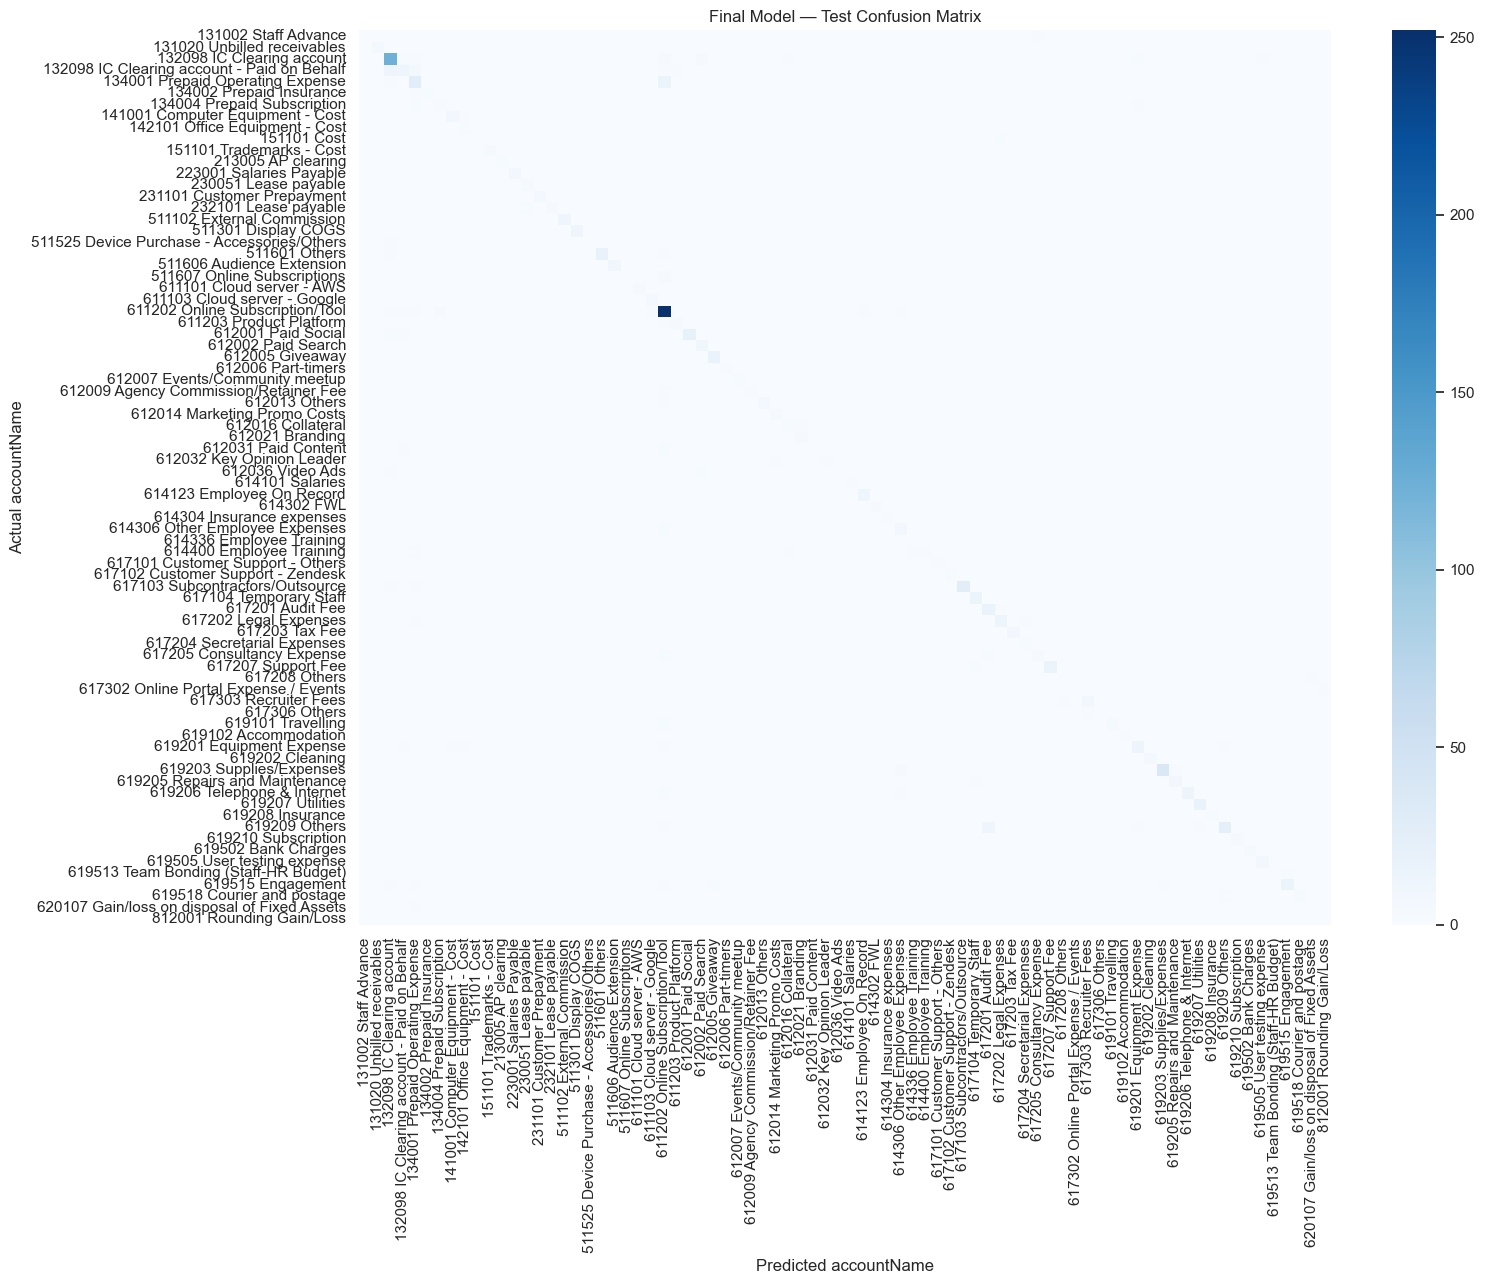

In [124]:
fig, ax = plt.subplots(figsize=(16, 13))

sns.heatmap(
    cm,
    cmap="Blues",
    xticklabels=classes,
    yticklabels=classes,
    ax=ax,
    cbar=True,
)

ax.set_title("Final Model — Test Confusion Matrix")
ax.set_xlabel("Predicted accountName")
ax.set_ylabel("Actual accountName")

plt.xticks(rotation=90)
plt.yticks(rotation=0)
plt.tight_layout()
plt.show()

# 13. Seen vs Unseen Vendor Generalization

Vendor information is useful, but it may generalize poorly to suppliers not observed during training.

This analysis helps distinguish genuine semantic generalization from vendor-specific memorization.

In [127]:
seen_vendors = set(X_dev["vendorId"])

seen_mask = X_test["vendorId"].isin(seen_vendors).to_numpy()
unseen_mask = ~seen_mask

print("Seen-vendor test rows:", int(seen_mask.sum()))
print("Unseen-vendor test rows:", int(unseen_mask.sum()))

if seen_mask.sum():
    print(
        "Seen-vendor accuracy:",
        f"{accuracy_score(y_test.iloc[seen_mask], final_predictions[seen_mask]) * 100:.2f}%"
    )

if unseen_mask.sum():
    print(
        "Unseen-vendor accuracy:",
        f"{accuracy_score(y_test.iloc[unseen_mask], final_predictions[unseen_mask]) * 100:.2f}%"
    )

Seen-vendor test rows: 976
Unseen-vendor test rows: 50
Seen-vendor accuracy: 87.70%
Unseen-vendor accuracy: 38.00%


# 14. Business / Deployment Considerations

A practical accounting classifier can combine automation with human review:

```text
Expense transaction
       |
       v
Classifier
       |
       +---- High confidence ----> Automatic classification
       |
       +---- Low confidence -----> Human review
                                      |
                                      v
                               Corrected label
                                      |
                                      v
                              Controlled retraining
```

Useful production monitoring includes model version, predicted account, vendor, confidence/margin, human overrides, unseen vendors, category drift and text drift.

# 15. Discussion

## Strengths

- `accountId` is excluded from model features.
- `_id` is used only for grouping.
- Text vectorization occurs inside the sklearn pipeline.
- Vendor/text mappings are training-only.
- Group-aware CV is used.
- The test set is frozen before model selection.
- Multiple model families are compared.
- Rare categories are retained.
- Category-level and confusion analysis are included.

## Limitations

- The supplied schema does not provide a clearly usable transaction date, so temporal validation cannot currently be performed.
- Many categories have very few examples, so minority metrics can be noisy.
- The meaning of `_id` should be confirmed with the data owner before production.
- Vendor-specific performance may degrade when new suppliers appear.
- A >90% score cannot honestly be guaranteed before the revised notebook is run on the supplied dataset.

## Further improvements

With more time, I would evaluate temporal validation, calibrated confidence, drift monitoring, class-specific features for the largest confusion pairs, and a controlled ensemble only if development-only validation shows a reproducible improvement.

# 17. Submission Checklist

- [x] Correct JSON loading for MongoDB `_id`
- [x] Expanded EDA
- [x] Missingness analysis
- [x] Duplicate/group analysis
- [x] Class imbalance analysis
- [x] Vendor concentration/purity analysis
- [x] Text repetition analysis
- [x] Amount analysis
- [x] `accountId` excluded
- [x] `_id` used only for grouping
- [x] Group-aware test split
- [x] Stratified group-aware CV
- [x] Word TF-IDF
- [x] Character TF-IDF
- [x] Vendor categorical encoding
- [x] Auxiliary numeric/text features
- [x] Regularized LinearSVC
- [x] Optional CatBoost comparison
- [x] Leakage-safe vendor/text lookup
- [x] Overfitting diagnostics
- [x] Category-level metrics
- [x] Confusion/error analysis
- [x] Seen/unseen vendor analysis
- [x] Deployment considerations

## Final methodological principle

The objective is not to manufacture a >90% score. The objective is to determine whether >90% is achievable **without target leakage and without test-set overfitting**.

If the revised pipeline exceeds 90% under this protocol, that is a much more defensible result for the Peakflo evaluation than a higher score obtained from random row-level splitting or target-derived features calculated over the full dataset.